# Application of spectrospatial models to LVM data of W28

Spatial-kinematic decomposition of line-of-sight components

## This notebook: ${\rm H}\alpha$

After we have the star mask from fitting [N II], let's fit ${\rm H}\alpha$. The reason we need this is that some of the stars have broad ${\rm H}\alpha$ absorption features that the model (as written) cannot fit, which causes things to go wrong. We can fix this by just masking the spaxels that have stars.

Most of this notebook is the same as `1_nii.ipynb` so I'll comment less frequently.

### Imports etc.

In [1]:
from pathlib import Path

import cmasher as cmr  # noqa: F401
import jax
import jax.numpy as jnp  # noqa: F401
import jax.random as jr
import matplotdrip  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
from lvm_tools import DataConfig, FitDataBuilder, LVMTile, LVMTileCollection
from lvm_tools.fit_data.filtering import BAD_FLUX_THRESHOLD
from lvm_tools.utils.mask import mask_near_points
from matplotdrip import colormaps  # noqa: F401
from two_lines import TwoComponentEmissionLine, neg_ln_posterior
from spectracles import (
    ConstrainedParameter,
    Known,
    Matern12,  # noqa: F401
    Matern32,  # noqa: F401
    Matern52,  # noqa: F401
    Parameter,
    SpatialDataGeneric,
    build_model,
    build_schedule,
    free_in,
    init_normal,
    save_model,
)

# Some declaration-y stuff
plt.style.use("drip")
rng = np.random.default_rng(0)
DATA_LOC = Path("../data/W28/THOR")
assert DATA_LOC.is_dir()
jax.config.update("jax_enable_x64", True)
RESULTS_LOC = Path("HALPHA")
if not RESULTS_LOC.is_dir():
    RESULTS_LOC.mkdir()
assert RESULTS_LOC.is_dir()

### Read in the data

In [2]:
LINE_λ = 6562.8  # Wavelength of Hα in Å
λ_EXTENT = 8.0  # Extract the region ±8 Å of the rest-frame line centre
norm_F = 5e-13  # A normalisation factor to make the data closer to scale order unity, which helps with fitting

In [3]:
# Load the data
drp_files = list(DATA_LOC.glob("*.fits"))
tiles = LVMTileCollection.from_tiles(
    [LVMTile.from_file(drp_file=drp_file) for drp_file in drp_files]
)
fd = FitDataBuilder(
    tiles=tiles,
    config=DataConfig.from_tiles(
        tiles,
        λ_range=(
            LINE_λ - λ_EXTENT,
            LINE_λ + λ_EXTENT,
        ),
        normalise_F_scale=norm_F,
        F_range=(BAD_FLUX_THRESHOLD, 1e-12),  # This excludes some stupid values
    ),
).build()

Make some plots

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/var/folders/dh/25w18bd96xxbvmf79kdjks9w0000gn/T/ipykernel_5896/2128417497.py:1: RuntimeWarning: All-NaN axis encountered
  peak_int_data = np.nanmax(fd._flux, axis=0)


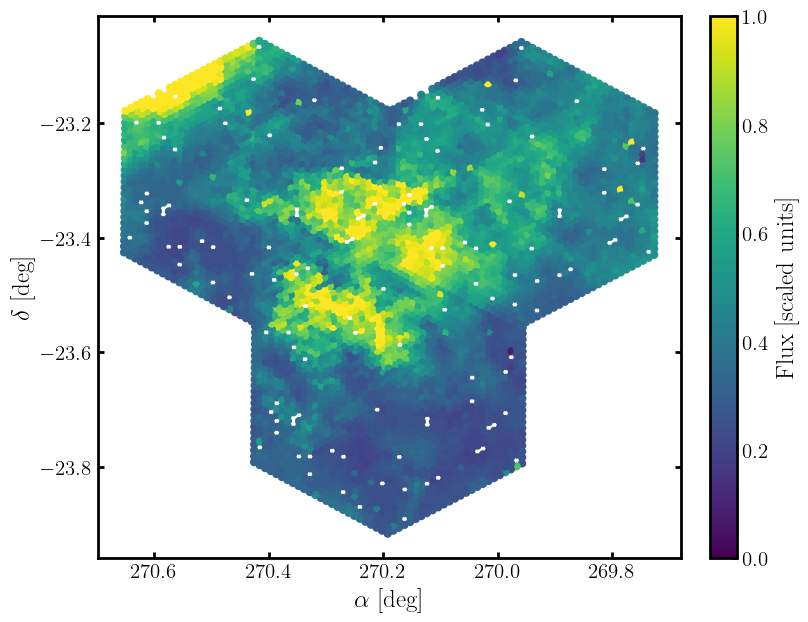

In [4]:
peak_int_data = np.nanmax(fd._flux, axis=0)

# Plot the data
fig, ax = plt.subplots(figsize=(8, 8), dpi=100, layout="compressed")
sc = ax.scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=peak_int_data,
    s=20,
    vmin=0,
    vmax=1,
)
ax.set_xlabel(r"$\alpha$ [deg]")
ax.set_ylabel(r"$\delta$ [deg]")
ax.set_aspect("equal")
ax.set_xlim(ax.get_xlim()[::-1])
plt.colorbar(sc, ax=ax, label="Flux [scaled units]")
plt.savefig(RESULTS_LOC / "peak_int.pdf", bbox_inches="tight")
plt.show()

Again, our peak is at about 1, which is what we want when we set `norm_F`.

Now plotting spectra

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return

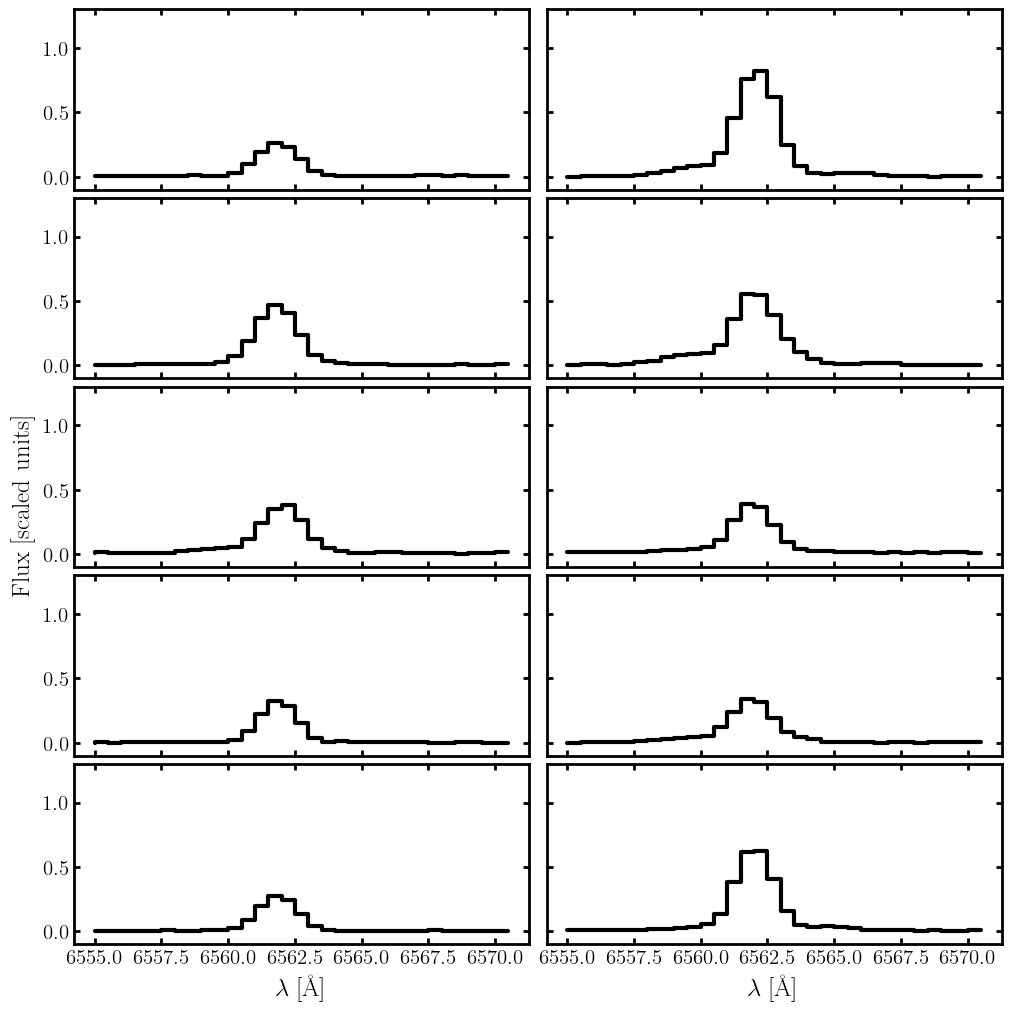

In [5]:
spax_inds = rng.choice(fd.α.shape[0], size=10, replace=False)
fig, axes = plt.subplots(
    5,
    2,
    figsize=(10, 10),
    dpi=100,
    sharex=True,
    sharey=True,
    layout="compressed",
)
for i, ax in enumerate(axes.flat):
    spax_ind = spax_inds[i]
    ax.step(fd.λ, fd.flux[:, spax_ind], color="k")
    ax.set_ylim(-0.1, 1.3)
for j in range(2):
    axes[-1, j].set_xlabel(r"$\lambda$ [\AA]")

fig.supylabel("Flux [scaled units]")
plt.savefig(RESULTS_LOC / "random_spectra.pdf", bbox_inches="tight")
plt.show()

### Mask star locations

Here's where we load and use the star mask from the [NII] fit.

In [6]:
# Try to load the star mask if it exists:
try:
    star_mask_loaded = np.load("star_mask.npy")
    star_mask_existed = True
    print("Star mask found and loaded.")
except FileNotFoundError:
    star_mask_loaded = np.ones_like(fd.mask, dtype=bool)
    star_mask_existed = False
    print("Star mask not found, stars not masked. Fit [NII] to get it.")

total_mask = np.logical_and(fd.mask, star_mask_loaded)

Star mask found and loaded.


/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


### Build and configure the model

In [7]:
# The number of Fourier modes used to approximate the Gaussian Processes. For 3 tiles, 201 x 201 is plenty (also it must always be odd numbers)
n_modes = (201, 201)

# Number of spaxels and index in wavelength where the line rest wavelength is
n_spaxels = fd.α.shape[0]
idx_λ = np.argmin(np.abs(fd.λ - LINE_λ))

# Stuff we have to give directly to the model but which is not fit for
line_centre = Known(LINE_λ)
σ_lsf = Known(fd.lsf_σ[idx_λ])
v_bary = Known(fd.v_bary)

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


Configure some Gaussian Process stuff.

In [8]:
# Kernel choice
kernel = Matern12

# Setup strictly positive parameters for the variance and length scale of the kernels
kernel_kwargs = dict(log=True)
A_var = ConstrainedParameter(10.0, **kernel_kwargs)
v_var = ConstrainedParameter(10.0, **kernel_kwargs)
σ_var = ConstrainedParameter(10.0, **kernel_kwargs)
A_len = ConstrainedParameter(1.0, **kernel_kwargs)
v_len = ConstrainedParameter(1.0, **kernel_kwargs)
σ_len = ConstrainedParameter(1.0, **kernel_kwargs)

# Build the kernels
A_kernel = kernel(variance=A_var, length_scale=A_len)
v_kernel = kernel(variance=v_var, length_scale=v_len)
σ_kernel = kernel(variance=σ_var, length_scale=σ_len)

Other parameters.

In [9]:
# Parameters with initial values
offsets = Parameter(np.zeros(n_spaxels))
v_syst = Parameter(-100.0)
Δv_syst = ConstrainedParameter(100.0, lower=0)

Make an instance of the model.

In [10]:
model = build_model(
    TwoComponentEmissionLine,
    n_spaxels=n_spaxels,
    offsets=offsets,
    line_centre=line_centre,
    n_modes=n_modes,
    A_kernel=A_kernel,
    v_kernel=v_kernel,
    σ_kernel=σ_kernel,
    σ_lsf=σ_lsf,
    v_bary=v_bary,
    v_syst=v_syst,
    Δv_syst=Δv_syst,
)

### Fitting

In [11]:
# First, evaluate the initial loss to check we don't get an error
initial_loss = neg_ln_posterior(
    model,
    λ=fd.λ,
    xy_data=fd.αδ_data,
    data=fd.flux,
    u_data=fd.u_flux,
    mask=fd.mask,
)
print(f"Initial loss: {initial_loss:.2f}")

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
2026-02-25 08:40:27.219778: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2


Initial loss: 149486946.16


We'll use the same schedule as for [NII].

In [12]:
n_step_base = 1000
lr_base = 0.01
schedule = build_schedule(
    model=model,
    loss_fn=neg_ln_posterior,
    phases=[
        (n_step_base, lr_base),  # steps, learning rate
        (n_step_base, lr_base),
        (n_step_base, lr_base),
        (n_step_base, lr_base),
        (n_step_base, lr_base),
        (2 * n_step_base, lr_base / 10),
        (2 * n_step_base, lr_base / 10),
        (2 * n_step_base, lr_base / 10),
    ],
    params={
        "*.A.gp.coefficients": init_normal(0) | free_in(0, 3, 4, 5),
        "*.v.gp.coefficients": init_normal(1) | free_in(1, 3, 4, 6),
        "*.vσ.gp.coefficients": init_normal(2) | free_in(2, 4, 7),
        "*.A.gp.kernel.length_scale": free_in(5),
        "*.A.gp.kernel.variance": free_in(5),
        "*.v.gp.kernel.length_scale": free_in(6),
        "*.v.gp.kernel.variance": free_in(6),
        "*.vσ.gp.kernel.length_scale": free_in(7),
        "*.vσ.gp.kernel.variance": free_in(7),
    },
    Δloss_criterion=1e-4,
    key=jr.key(42),
)

In [13]:
schedule.run_all(
    λ=fd.λ,
    xy_data=fd.αδ_data,
    data=fd.flux,
    u_data=fd.u_flux,
    mask=total_mask,
)

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
Optimising:   0%|          | 0/1000 [00:00<?, ?step/s]2026-02-25 08:40:29.003186: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2
2026-02-25 08:40:29.003356: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will 

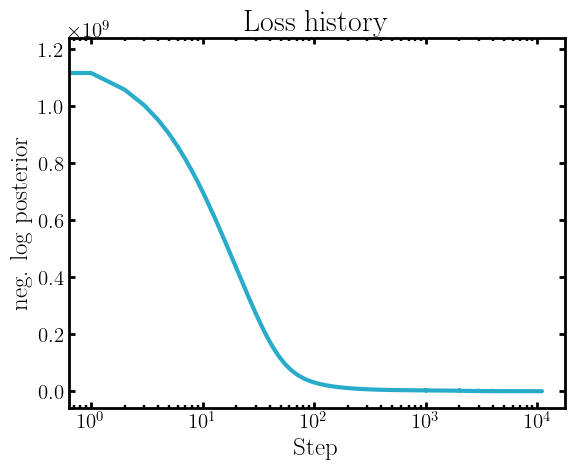

In [14]:
# Plot the loss history
plt.figure()
plt.title("Loss history")
plt.plot(schedule.loss_history)
plt.xscale("log")
plt.xlabel("Step")
plt.ylabel("neg. log posterior")
plt.savefig(RESULTS_LOC / "loss_history.pdf", bbox_inches="tight")
plt.show()

In [15]:
final_model = schedule.model_history[-1]
pred_model = final_model.get_locked_model()

print("=== Final parameter values:")
print(f"v_syst_1: {pred_model.line_1.v_syst.val[0]:.2f} km/s")
print(f"v_syst_2: {pred_model.line_2.v_syst.val[0]:.2f} km/s")

print("=== Final kernel parameters:")

print("= Line flux GPs")
print(f"variance: {pred_model.line_1.A.gp.kernel.variance.val[0]:.2f}")
print(f"length scale: {pred_model.line_1.A.gp.kernel.length_scale.val[0]:.2f}")

print("= Radial velocity GPs")
print(f"variance: {pred_model.line_1.v.gp.kernel.variance.val[0]:.2f}")
print(f"length scale: {pred_model.line_1.v.gp.kernel.length_scale.val[0]:.2f}")

print("= Velocity dispersion GPs")
print(f"variance: {pred_model.line_1.vσ.gp.kernel.variance.val[0]:.2f}")
print(f"length scale: {pred_model.line_1.vσ.gp.kernel.length_scale.val[0]:.2f}")

=== Final parameter values:
v_syst_1: -89.36 km/s
v_syst_2: 4.26 km/s
=== Final kernel parameters:
= Line flux GPs
variance: 4.25
length scale: 3.87
= Radial velocity GPs
variance: 20.99
length scale: 1.98
= Velocity dispersion GPs
variance: 6.80
length scale: 1.70


### Plotting results!

In [16]:
n_dense = 800
α_dense_1D = np.linspace(fd.α.min(), fd.α.max(), n_dense)
δ_dense_1D = np.linspace(fd.δ.min(), fd.δ.max(), n_dense)

mask = mask_near_points(
    xgrid=α_dense_1D,
    ygrid=δ_dense_1D,
    xpoints=fd.α,
    ypoints=fd.δ,
    threshold=0.05,
)
α_dense, δ_dense = np.meshgrid(α_dense_1D, δ_dense_1D)
αδ_dense = SpatialDataGeneric(
    α_dense.flatten(),
    δ_dense.flatten(),
    idx=np.arange(n_dense**2, dtype=int),
)

A_pred_1 = pred_model.line_1.A(αδ_dense).reshape(n_dense, n_dense)
A_pred_2 = pred_model.line_2.A(αδ_dense).reshape(n_dense, n_dense)
v_pred_1 = pred_model.line_1.v(αδ_dense).reshape(n_dense, n_dense)
v_pred_2 = pred_model.line_2.v(αδ_dense).reshape(n_dense, n_dense)
vσ_pred_1 = pred_model.line_1.vσ(αδ_dense).reshape(n_dense, n_dense)
vσ_pred_2 = pred_model.line_2.vσ(αδ_dense).reshape(n_dense, n_dense)

A_pred_1 = fd.predict_flux(np.where(mask, A_pred_1, np.nan)) / 1e-12
A_pred_2 = fd.predict_flux(np.where(mask, A_pred_2, np.nan)) / 1e-12
v_pred_1 = np.where(mask, v_pred_1, np.nan)
v_pred_2 = np.where(mask, v_pred_2, np.nan)
vσ_pred_1 = np.where(mask, vσ_pred_1, np.nan)
vσ_pred_2 = np.where(mask, vσ_pred_2, np.nan)

v_pred_1_with_syst = v_pred_1 + pred_model.line_1.v_syst.val
v_pred_2_with_syst = v_pred_2 + pred_model.line_2.v_syst.val

2026-02-25 08:44:56.825023: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2


In [37]:
A_vmin, A_vmax = 0, max(np.nanmax(A_pred_1), np.nanmax(A_pred_2))
max_abs_v = 0.9 * max(np.nanmax(np.abs(v_pred_1)), np.nanmax(np.abs(v_pred_2)))
v_vmin, v_vmax = -max_abs_v, max_abs_v
vσ_vmin, vσ_vmax = (
    min(np.nanmin(vσ_pred_1), np.nanmin(vσ_pred_2)),
    max(np.nanmax(vσ_pred_1), np.nanmax(vσ_pred_2)),
)

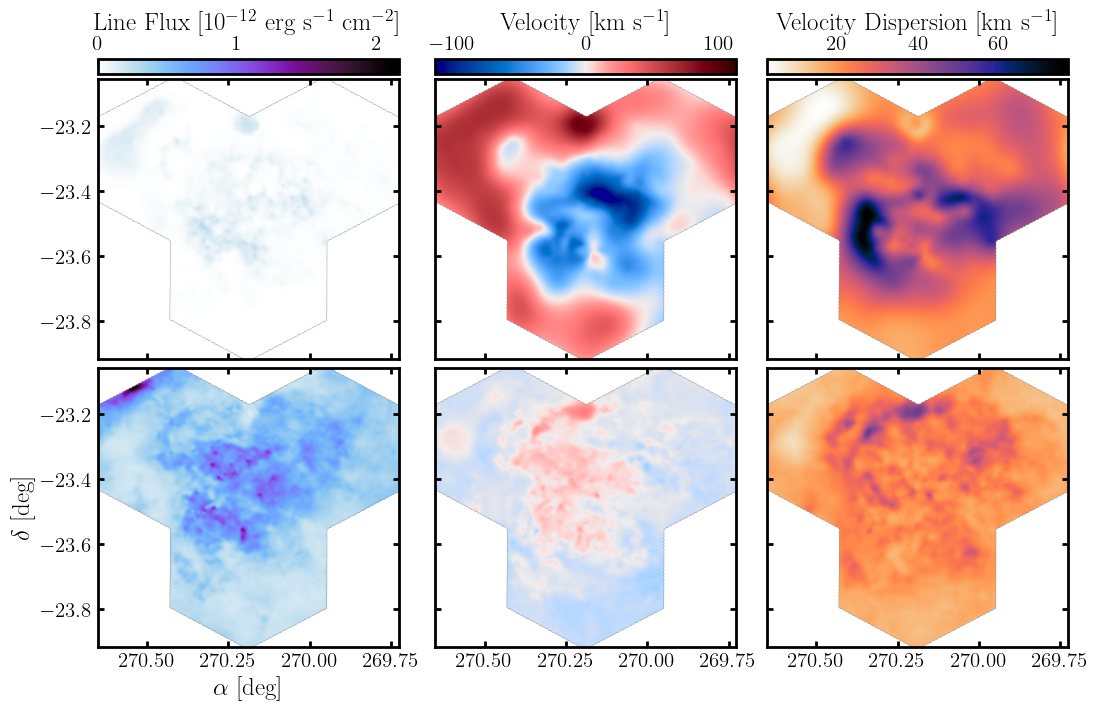

In [38]:
extent = (
    fd.predict_α(fd.α.min()),
    fd.predict_α(fd.α.max()),
    fd.predict_δ(fd.δ.min()),
    fd.predict_δ(fd.δ.max()),
)
all_kwargs = dict(origin="lower", extent=extent)
A_imshow_kwargs = dict(vmin=A_vmin, vmax=A_vmax, cmap="cmr.voltage_r", **all_kwargs)
v_imshow_kwargs = dict(vmin=v_vmin, vmax=v_vmax, cmap="red_white_blue_r", **all_kwargs)
σ_imshow_kwargs = dict(vmin=vσ_vmin, vmax=vσ_vmax, cmap="cmr.torch_r", **all_kwargs)
cbar_kwargs = dict(orientation="horizontal", location="top", pad=0.01)

fig, ax = plt.subplots(
    2,
    3,
    figsize=(15, 7),
    dpi=100,
    layout="compressed",
    sharex=True,
    sharey=True,
)
im = ax[0, 0].imshow(A_pred_1, **A_imshow_kwargs)
im = ax[1, 0].imshow(A_pred_2, **A_imshow_kwargs)
plt.colorbar(
    im,
    ax=ax[:, 0],
    label=r"Line Flux [10$^{-12}$ erg s$^{-1}$ cm$^{-2}$]",
    **cbar_kwargs,
)
im = ax[0, 1].imshow(v_pred_1, **v_imshow_kwargs)
im = ax[1, 1].imshow(v_pred_2, **v_imshow_kwargs)
# im = ax[0, 1].imshow(v_pred_1_with_syst, **v_imshow_kwargs)
# im = ax[1, 1].imshow(v_pred_2_with_syst, **v_imshow_kwargs)
plt.colorbar(im, ax=ax[:, 1], label=r"Velocity [km s$^{-1}$]", **cbar_kwargs)
im = ax[0, 2].imshow(vσ_pred_1, **σ_imshow_kwargs)
im = ax[1, 2].imshow(vσ_pred_2, **σ_imshow_kwargs)
plt.colorbar(im, ax=ax[:, 2], label=r"Velocity Dispersion [km s$^{-1}$]", **cbar_kwargs)

ax[-1, 0].set_xlabel(r"$\alpha$ [deg]")
ax[-1, 0].set_ylabel(r"$\delta$ [deg]")

ax[-1, -1].set_xlim(ax[-1, -1].get_xlim()[::-1])

plt.savefig(RESULTS_LOC / "line_property_fields.pdf", bbox_inches="tight")
plt.show()

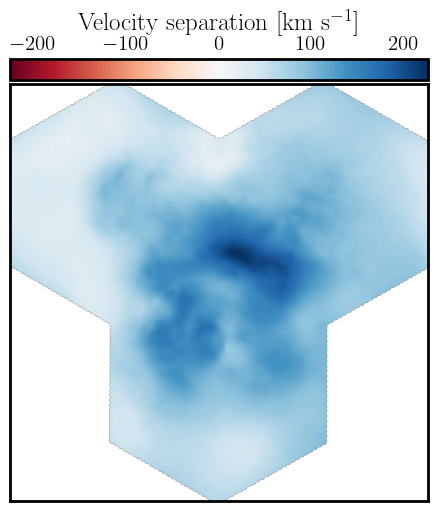

In [19]:
v_sep = v_pred_2_with_syst - v_pred_1_with_syst
v_sep = np.where(mask, v_sep, np.nan)
max_v_sep = np.nanmax(np.abs(v_sep))
fig, ax = plt.subplots(figsize=(5, 5), dpi=100, layout="compressed")
im = ax.imshow(v_sep, cmap="RdBu", vmin=-max_v_sep, vmax=max_v_sep, origin="lower")
ax.set_xlim(ax.get_xlim()[::-1])
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, label=r"Velocity separation [km s$^{-1}$]", **cbar_kwargs)
plt.savefig(RESULTS_LOC / "velocity_separation.pdf", bbox_inches="tight")
plt.show()

In [20]:
# 200 wavelength points
λ_dense = np.linspace(fd.λ.min(), fd.λ.max(), 200)

# Evaluate the model on the dense λ grid, but the actual data spaxel locations
pred_flux_λ_dense = jax.vmap(pred_model, in_axes=(0, None))(λ_dense, fd.αδ_data)

# Do the same for the individual lines along
pred_flux_λ_dense_comp_1 = jax.vmap(pred_model.line_1, in_axes=(0, None))(
    λ_dense, fd.αδ_data
)
pred_flux_λ_dense_comp_2 = jax.vmap(pred_model.line_2, in_axes=(0, None))(
    λ_dense, fd.αδ_data
)

# And the continuum component
pred_flux_λ_dense_offs = jax.vmap(pred_model.offs, in_axes=(0, None))(
    λ_dense, fd.αδ_data
)

# Add the continuum to each line component so that the plotting lines up
pred_flux_λ_dense_comp_1 = pred_flux_λ_dense_comp_1 + pred_flux_λ_dense_offs
pred_flux_λ_dense_comp_2 = pred_flux_λ_dense_comp_2 + pred_flux_λ_dense_offs

2026-02-25 08:44:59.202038: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2


/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return

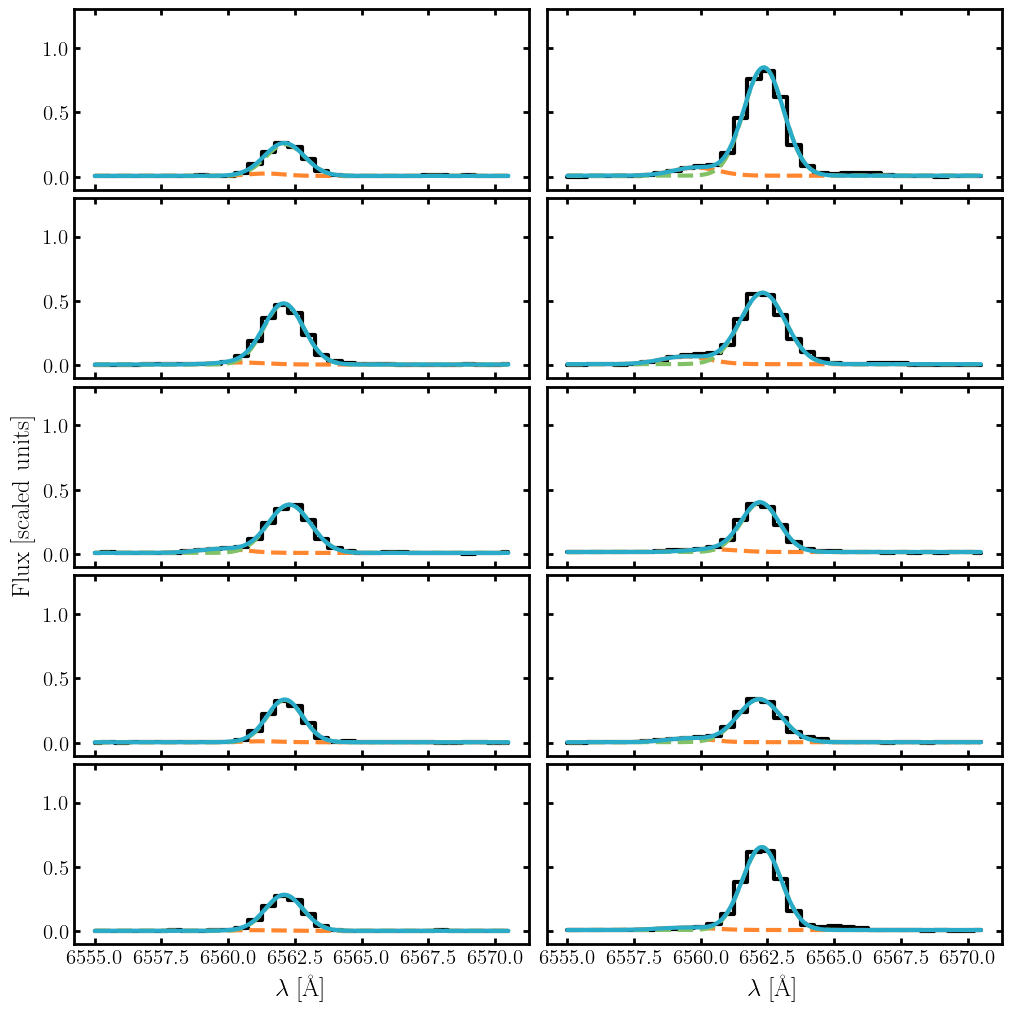

In [21]:
# Plot the model spectra for the same random spaxels as before, to see how the model fits the data
fig, axes = plt.subplots(
    5,
    2,
    figsize=(10, 10),
    dpi=100,
    sharex=True,
    sharey=True,
    layout="compressed",
)
for i, ax in enumerate(axes.flat):
    spax_ind = spax_inds[i]
    ax.step(fd.λ, fd._flux[:, spax_ind], c="k", where="mid", zorder=-2)
    ax.plot(λ_dense, pred_flux_λ_dense[:, spax_ind], c="C0")
    ax.plot(λ_dense, pred_flux_λ_dense_comp_1[:, spax_ind], c="C1", ls="--", zorder=-1)
    ax.plot(λ_dense, pred_flux_λ_dense_comp_2[:, spax_ind], c="C2", ls="--", zorder=-1)
    ax.set_ylim(-0.1, 1.3)
for j in range(2):
    axes[-1, j].set_xlabel(r"$\lambda$ [\AA]")

fig.supylabel("Flux [scaled units]")
plt.savefig(RESULTS_LOC / "random_spectra.pdf", bbox_inches="tight")
plt.show()

2026-02-25 08:45:01.000338: E external/xla/xla/backends/cpu/runtime/custom_call_thunk.cc:209] Custom call API version `API_VERSION_STATUS_RETURNING` is not supported by XLA:CPU. Prefer https://docs.jax.dev/en/latest/ffi.html. It will be fully removed in November 2025. Custom call target: nufft2d2


Number of spaxels where model is active in both components: 433


/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return

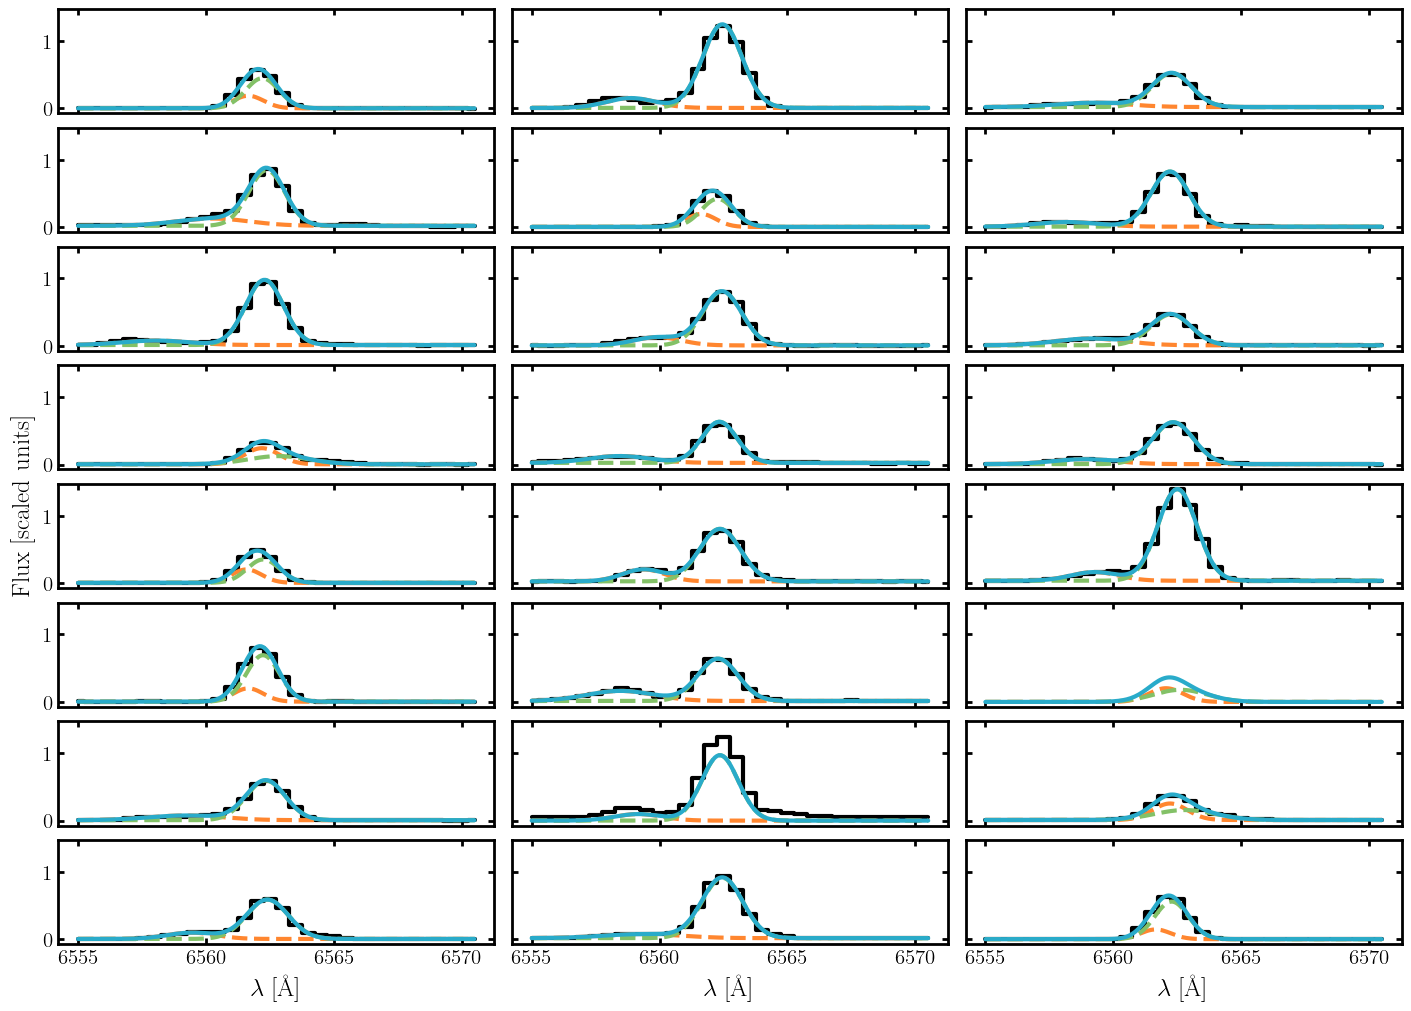

In [22]:
### Evaluate on the actual data points
A_pred_1_dp = pred_model.line_1.A(fd.αδ_data)
v_pred_1_dp = pred_model.line_1.v(fd.αδ_data) + pred_model.line_1.v_syst.val
vσ_pred_1_dp = pred_model.line_1.vσ(fd.αδ_data)
A_pred_2_dp = pred_model.line_2.A(fd.αδ_data)
v_pred_2_dp = pred_model.line_2.v(fd.αδ_data) + pred_model.line_2.v_syst.val
vσ_pred_2_dp = pred_model.line_2.vσ(fd.αδ_data)

# Filer spaxel indices for which the model predicts a line flux in both components above the normalisation scale (i.e. where the model is "active" in both components)
threshold = 0.2
active_spax_inds = np.where(
    (A_pred_1_dp.flatten() > threshold) & (A_pred_2_dp.flatten() > threshold)
)[0]
print(
    f"Number of spaxels where model is active in both components: {len(active_spax_inds)}"
)

### Plot in spaxel indices where both lines are active
spax_inds_both_lines_active = rng.choice(active_spax_inds, size=24, replace=False)

# Make the plot
fig, axes = plt.subplots(
    8,
    3,
    figsize=(14, 10),
    dpi=100,
    sharex=True,
    sharey=True,
    layout="compressed",
)
for i, ax in enumerate(axes.flat):
    spax_ind = spax_inds_both_lines_active[i]
    ax.step(fd.λ, fd._flux[:, spax_ind], c="k", where="mid", zorder=-2)
    ax.plot(λ_dense, pred_flux_λ_dense[:, spax_ind], c="C0")
    ax.plot(λ_dense, pred_flux_λ_dense_comp_1[:, spax_ind], c="C1", ls="--", zorder=-1)
    ax.plot(λ_dense, pred_flux_λ_dense_comp_2[:, spax_ind], c="C2", ls="--", zorder=-1)
    # ax.set_ylim(-0.1, 1.3)
    # ax.set_yscale("log")
for j in range(3):
    axes[-1, j].set_xlabel(r"$\lambda$ [\AA]")

fig.supylabel("Flux [scaled units]")
plt.savefig(RESULTS_LOC / "spectra_both_components_large.pdf", bbox_inches="tight")
plt.show()

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


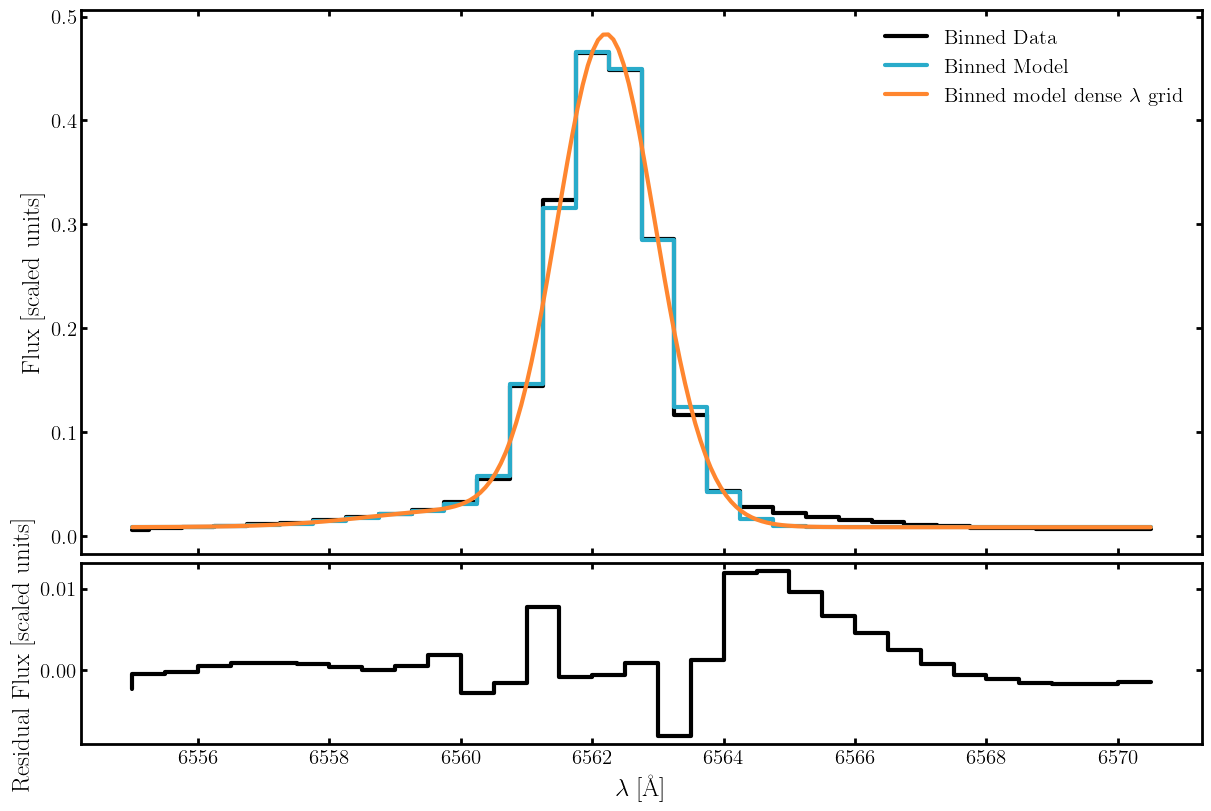

In [39]:
masked_flux = fd._flux.at[~total_mask].set(np.nan)
binned_spec_data = np.nanmean(masked_flux, axis=1)

# Evaluate on wavelength grid and spaxels of original data
pred_flux = jax.vmap(pred_model, in_axes=(0, None))(fd.λ, fd.αδ_data)
binned_spec_model = np.nanmean(pred_flux, axis=1)

# Binned spectrum on dense wavelength grid
binned_spec_dense = np.nanmean(pred_flux_λ_dense, axis=1)

fig, ax = plt.subplots(
    2,
    1,
    figsize=[12, 8],
    dpi=100,
    sharex=True,
    height_ratios=[3, 1],
    layout="compressed",
)
ax[0].step(fd.λ, binned_spec_data, c="k", where="mid", label="Binned Data")
ax[0].step(fd.λ, binned_spec_model, c="C0", where="mid", label="Binned Model")
ax[0].plot(
    λ_dense, binned_spec_dense, c="C1", label=r"Binned model dense $\lambda$ grid"
)
ax[1].step(fd.λ, binned_spec_data - binned_spec_model, c="k")
ax[0].set_ylabel(r"Flux [scaled units]")
ax[1].set_ylabel(r"Residual Flux [scaled units]")
ax[1].set_xlabel(r"$\lambda$ [\AA]")
ax[0].legend(loc="best")
plt.savefig(RESULTS_LOC / "binnned_spec_comparison.pdf", bbox_inches="tight")
plt.show()

Looks pretty similar to the [NII] residuals. Similar evidence for a redshifted component.

/Users/tomhilder/Documents/PhD/research/lvm_snr_spectrospatial/.venv/lib/python3.13/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/var/folders/dh/25w18bd96xxbvmf79kdjks9w0000gn/T/ipykernel_5896/4120833620.py:1: RuntimeWarning: All-NaN axis encountered
  peak_int_data = np.nanmax(fd._flux, axis=0)


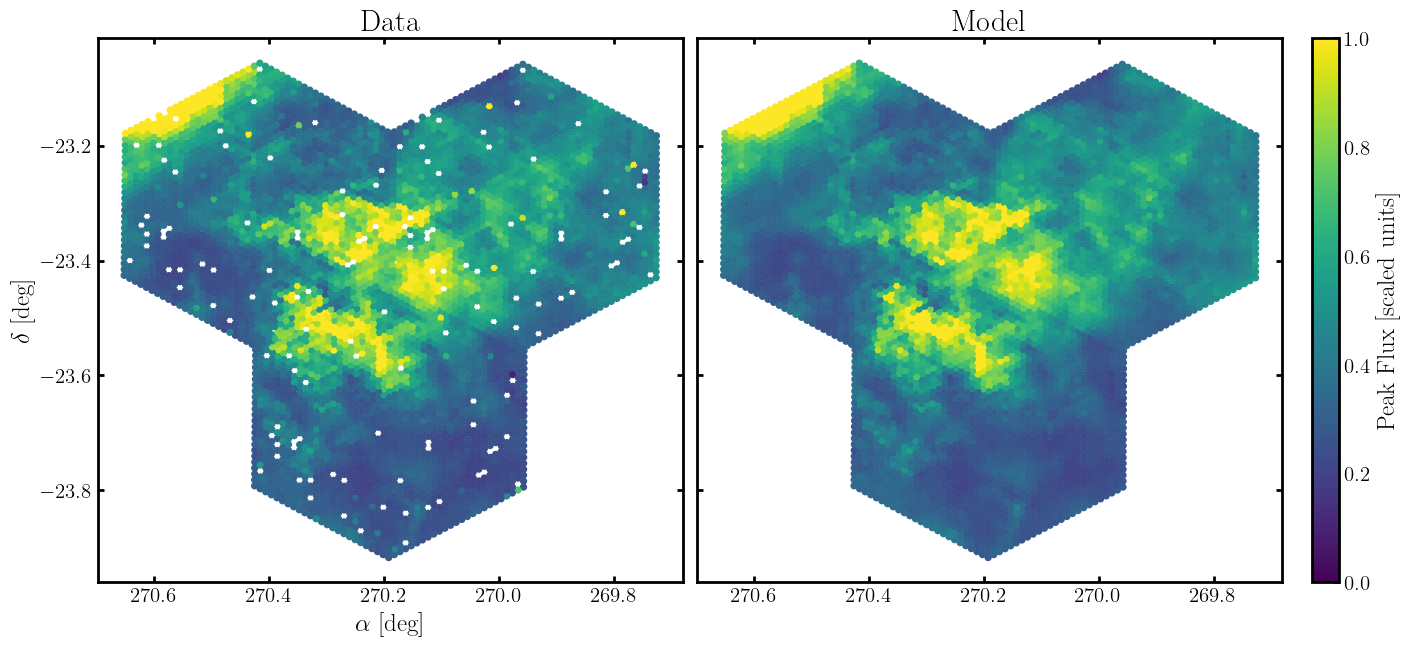

In [30]:
peak_int_data = np.nanmax(fd._flux, axis=0)
peak_int_model = np.nanmax(pred_flux, axis=0)

# Plot the data
fig, ax = plt.subplots(
    1, 2, figsize=(14, 14), dpi=100, layout="compressed", sharex=True, sharey=True
)
scatter_kwargs = dict(s=14, vmin=0, vmax=1.0)
sc0 = ax[0].scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=peak_int_data,
    **scatter_kwargs,
)
ax[0].set_title("Data")
sc1 = ax[1].scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=peak_int_model,
    **scatter_kwargs,
)
ax[1].set_title("Model")
ax[0].set_xlabel(r"$\alpha$ [deg]")
ax[0].set_ylabel(r"$\delta$ [deg]")
ax[0].set_aspect("equal")
ax[0].set_xlim(ax[0].get_xlim()[::-1])
plt.colorbar(sc1, ax=ax[-1], label="Peak Flux [scaled units]")
plt.savefig(RESULTS_LOC / "peak_int_comparison.pdf", bbox_inches="tight")
plt.show()

The continuum offsets will all be much smaller this time since we masked the stars

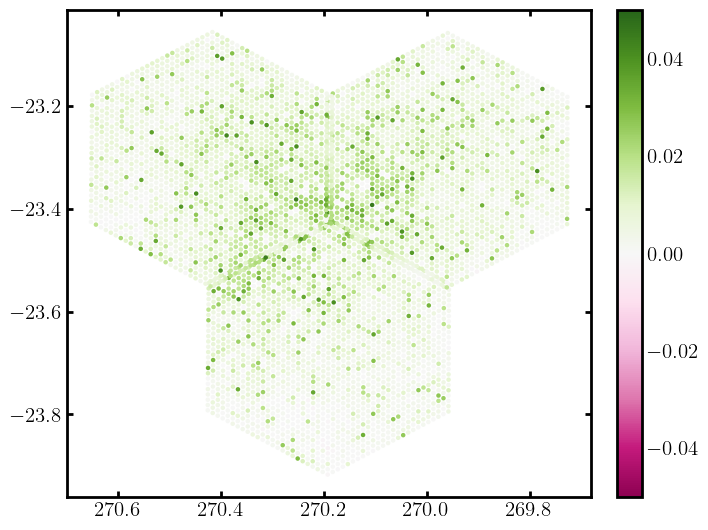

In [25]:
cont = pred_model.offs.const(fd.αδ_data)

fig, ax = plt.subplots(figsize=[7, 7], layout="compressed")
sc = ax.scatter(
    fd.predict_α(fd.α),
    fd.predict_δ(fd.δ),
    c=cont,
    s=3,
    vmin=-0.05,
    vmax=0.05,
    cmap="PiYG",
)
ax.set_xlim(ax.get_xlim()[::-1])
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax)
plt.savefig(RESULTS_LOC / "per_spaxel_cont.pdf")
plt.show()

### Save the model to disk

In [26]:
save_model(final_model, RESULTS_LOC / "optimised.model", overwrite=True)